#**NFL Draft First-Round Pick Prediction**

##RMU Sports Analytics Competition — 2026 Draft Class

## Introduction

The 2026 NFL Draft is coming to Pittsburgh — and for a sports memorabilia company in the Strip District, that means one thing: knowing what to stock. Our boss wants to capitalize on the influx of foot traffic by ordering college memorabilia for first-round talent, since first-round players are expected to generate the highest sales. He needs a data-driven answer to one question: *which offensive skill position prospects should we bet on?*

To answer this, we developed three separate logistic regression models — one each for quarterbacks, wide receivers, and running backs — trained on historical NFL Draft data from 2010 to 2024. We chose position-specific models because each position is evaluated on fundamentally different criteria, and a single combined model would obscure those differences. We selected logistic regression specifically because it produces interpretable probability outputs, performs well on relatively small datasets, and generates coefficient plots that clearly communicate which factors drive first-round selection — all of which are essential for making a credible business recommendation.

Each model was evaluated using repeated stratified k-fold cross-validation with AUC-ROC as our primary metric, chosen over accuracy to account for the significant class imbalance inherent in draft data — most prospects are never first-round picks. We then pooled predicted probabilities across all three models into a unified cross-position ranking, setting our first-round threshold at 0.539, calibrated to the historical average of 8 skill position first-rounders per draft class from 2010 to 2024.

Our final recommendation to our boss: prioritize inventory for **Jeremiyah Love, Fernando Mendoza, and Omar Cooper Jr.**, the three prospects with the highest and most confident first-round probabilities across all positions.

## Imports & Data Upload

In [ ]:
# Imports #

import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
import seaborn as sns

#logistic regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="white", palette="Set2", font='sans-serif')

In [ ]:
# Data #

TrainingData = "/content/drive/MyDrive/DATA/NFL Draft Competition/TrainingData"
TestingData = "/content/drive/MyDrive/DATA/NFL Draft Competition/TestingData"

qb_train = pd.read_csv(TrainingData + "/QB_train.csv", index_col=0)
rb_train = pd.read_csv(TrainingData + "/RB_train.csv", index_col=0)
wr_train = pd.read_csv(TrainingData + "/WR_train.csv", index_col=0)
qb_test = pd.read_csv(TestingData + "/QB_Test.csv")
rb_test = pd.read_csv(TestingData + "/RB_Test.csv")
wr_test = pd.read_csv(TestingData + "/WR_Test.csv")

In [ ]:
qb_train

,college_team,college_conference,nfl_team,year,overall,round,pick,name,position,height,...,postseason_games,postseason_wins,postseason_losses,forty,bench,vertical,broad_jump,cone,shuttle,attended_combine
1,Oklahoma,Big 12,Los Angeles,2010,1,1,1,Sam Bradford,Quarterback,76.0,...,1,1,0,4.79,NaN,NaN,NaN,NaN,NaN,Y
2,Florida,SEC,Denver,2010,25,1,25,Tim Tebow,Quarterback,75.0,...,1,1,0,4.71,NaN,38.5,115.0,6.66,4.17,Y
3,Notre Dame,FBS Independents,Carolina,2010,48,2,16,Jimmy Clausen,Quarterback,75.0,...,0,0,0,4.76,NaN,NaN,NaN,NaN,NaN,Y
4,Texas,Big 12,Cleveland,2010,85,3,21,Colt McCoy,Quarterback,73.0,...,1,0,1,4.79,NaN,NaN,114.0,NaN,NaN,Y
5,Tennessee,SEC,Los Angeles,2010,168,5,37,Jonathan Crompton,Quarterback,75.0,...,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,South Carolina,SEC,New Orleans,2024,150,5,15,Spencer Rattler,Quarterback,72.0,...,0,0,0,4.95,NaN,32.0,108.0,7.21,4.37,Y
161,Florida State,ACC,New York,2024,171,5,36,Jordan Travis,Quarterback,73.0,...,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,Y
162,Tennessee,SEC,New England,2024,193,6,17,Joe Milton III,Quarterback,77.0,...,1,1,0,NaN,NaN,35.0,121.0,NaN,NaN,Y
163,Kentucky,SEC,Baltimore,2024,218,6,42,Devin Leary,Quarterback,73.0,...,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,Y


## QB Analysis

In [ ]:
# See the features visually #

print(qb_train.columns, "\n\n", "****" * 20, "\n")
qb_train["first_round"] = np.where(qb_train["round"] == 1, 1, 0)

qb_train.head()

Index(['college_team', 'college_conference', 'nfl_team', 'year', 'overall',
       'round', 'pick', 'name', 'position', 'height', 'weight',
       'season_before_draft', 'passing_completions', 'passing_att',
       'completion_pct', 'passing_yds', 'passing_td', 'passing_int',
       'passing_ypa', 'rushing_car', 'rushing_yds', 'rushing_td',
       'rushing_ypc', 'regular_season_games', 'regular_season_wins',
       'regular_season_losses', 'postseason_games', 'postseason_wins',
       'postseason_losses', 'forty', 'bench', 'vertical', 'broad_jump', 'cone',
       'shuttle', 'attended_combine'],
      dtype='object') 

 ******************************************************************************** 



,college_team,college_conference,nfl_team,year,overall,round,pick,name,position,height,...,postseason_wins,postseason_losses,forty,bench,vertical,broad_jump,cone,shuttle,attended_combine,first_round
1,Oklahoma,Big 12,Los Angeles,2010,1,1,1,Sam Bradford,Quarterback,76.0,...,1,0,4.79,NaN,NaN,NaN,NaN,NaN,Y,1
2,Florida,SEC,Denver,2010,25,1,25,Tim Tebow,Quarterback,75.0,...,1,0,4.71,NaN,38.5,115.0,6.66,4.17,Y,1
3,Notre Dame,FBS Independents,Carolina,2010,48,2,16,Jimmy Clausen,Quarterback,75.0,...,0,0,4.76,NaN,NaN,NaN,NaN,NaN,Y,0
4,Texas,Big 12,Cleveland,2010,85,3,21,Colt McCoy,Quarterback,73.0,...,0,1,4.79,NaN,NaN,114.0,NaN,NaN,Y,0
5,Tennessee,SEC,Los Angeles,2010,168,5,37,Jonathan Crompton,Quarterback,75.0,...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,N,0


### Feature Engineering

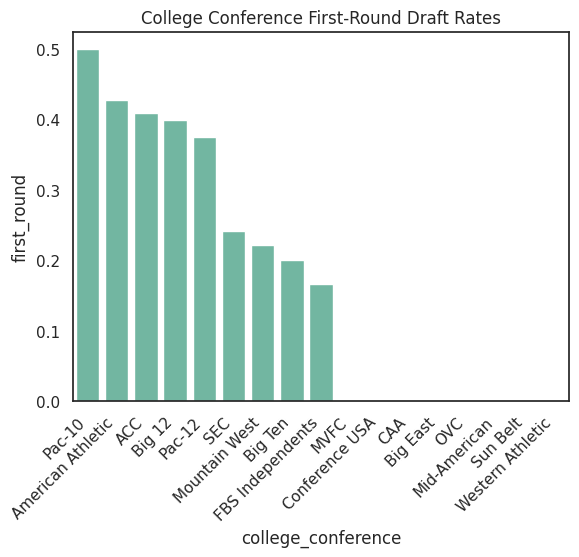

In [ ]:
college_conference_summary = qb_train.groupby("college_conference")["first_round"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=college_conference_summary, x = "college_conference", y = "first_round")
plt.xticks(rotation=45, ha="right")
plt.title("College Conference First-Round Draft Rates")
plt.show()

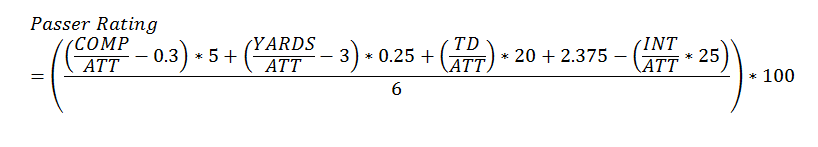

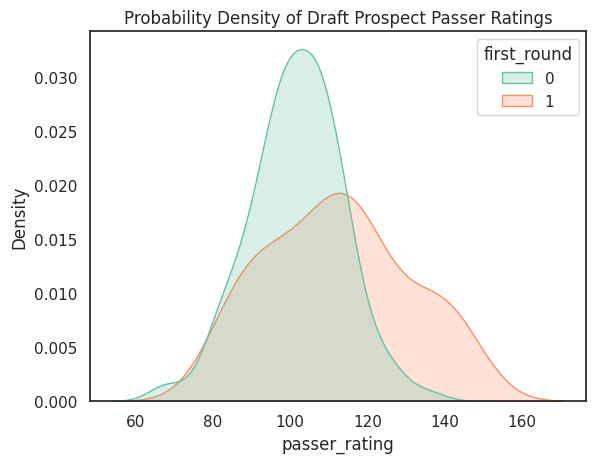

In [ ]:
def getPasserRating(completions, attempts, yards, td, ints):
    valid = attempts > 0
    a = np.where(valid, np.clip((completions/attempts.where(valid, 1) - 0.3) * 5, 0, 2.375), 0)
    b = np.where(valid, np.clip((yards/attempts.where(valid, 1) - 3) * 0.25, 0, 2.375), 0)
    c = np.where(valid, np.clip((td/attempts.where(valid, 1)) * 20, 0, 2.375), 0)
    d = np.where(valid, np.clip(2.375 - (ints/attempts.where(valid, 1)) * 25, 0, 2.375), 0)
    return ((a + b + c + d) / 6) * 100

qb_train["passer_rating"] = getPasserRating(qb_train["passing_completions"], qb_train["passing_att"], qb_train["passing_yds"], qb_train["passing_td"], qb_train["passing_int"])

sns.kdeplot(qb_train, x="passer_rating", fill=True, hue="first_round", common_norm=False)
plt.title("Probability Density of Draft Prospect Passer Ratings")
plt.show()

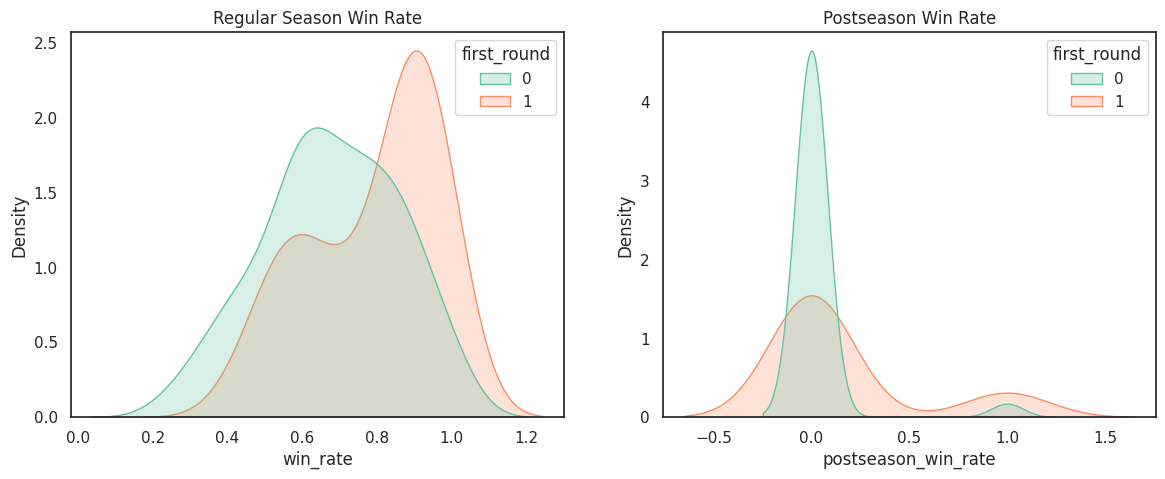

In [ ]:
qb_train["win_rate"] = qb_train["regular_season_wins"] / qb_train["regular_season_games"]
qb_train["postseason_win_rate"] = qb_train["postseason_wins"] / qb_train["postseason_losses"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(qb_train, x = "win_rate", hue="first_round", fill=True, ax=ax1, common_norm=False)
ax1.set_title("Regular Season Win Rate")
sns.kdeplot(qb_train, x = "postseason_win_rate", hue = "first_round", fill = True, ax=ax2, common_norm=False)
ax2.set_title("Postseason Win Rate")
plt.show()

Note that the CFP changing makes it such that the postseason_win_rate is a bad feature to add***

In [ ]:
qb_train.columns

Index(['college_team', 'college_conference', 'nfl_team', 'year', 'overall',
       'round', 'pick', 'name', 'position', 'height', 'weight',
       'season_before_draft', 'passing_completions', 'passing_att',
       'completion_pct', 'passing_yds', 'passing_td', 'passing_int',
       'passing_ypa', 'rushing_car', 'rushing_yds', 'rushing_td',
       'rushing_ypc', 'regular_season_games', 'regular_season_wins',
       'regular_season_losses', 'postseason_games', 'postseason_wins',
       'postseason_losses', 'forty', 'bench', 'vertical', 'broad_jump', 'cone',
       'shuttle', 'attended_combine', 'first_round', 'passer_rating',
       'win_rate', 'postseason_win_rate'],
      dtype='object')

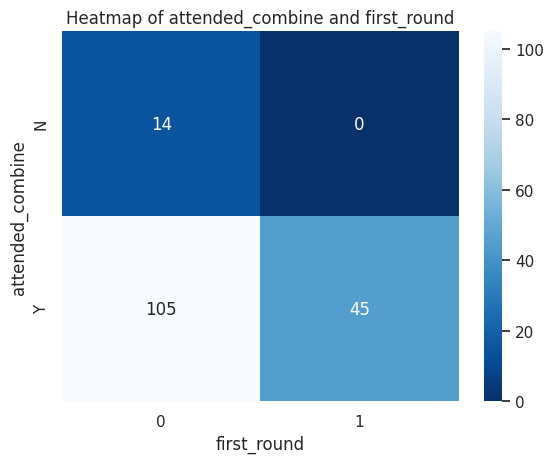

In [ ]:
ct = pd.crosstab(qb_train["attended_combine"], qb_train["first_round"], margins=False)
sns.heatmap(ct, annot=True, cmap = "Blues_r", fmt='d')
plt.title("Heatmap of attended_combine and first_round")
plt.show()

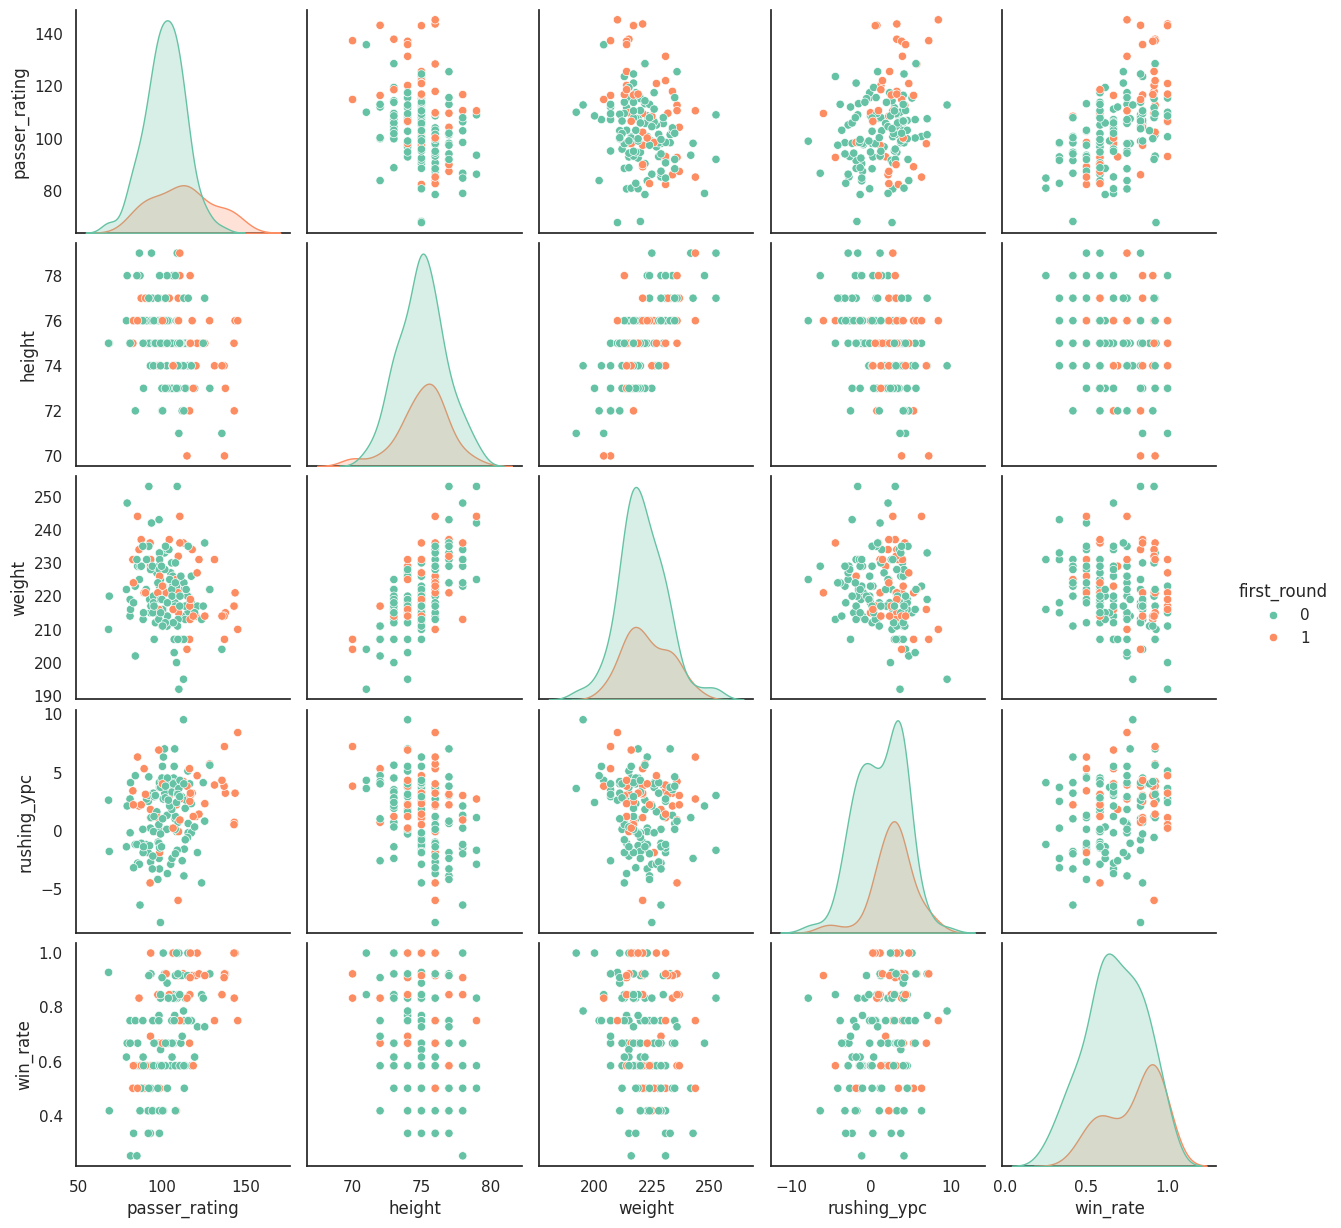

In [ ]:
qb_features = ["passer_rating","height", "weight", "rushing_ypc", "win_rate"]
sns.pairplot(qb_train, vars = qb_features, hue="first_round")
plt.show()

In [ ]:
qb_train.query("attended_combine == 'N' and first_round == 1")

## All first round QBs attended the combine.

,college_team,college_conference,nfl_team,year,overall,round,pick,name,position,height,...,bench,vertical,broad_jump,cone,shuttle,attended_combine,first_round,passer_rating,win_rate,postseason_win_rate


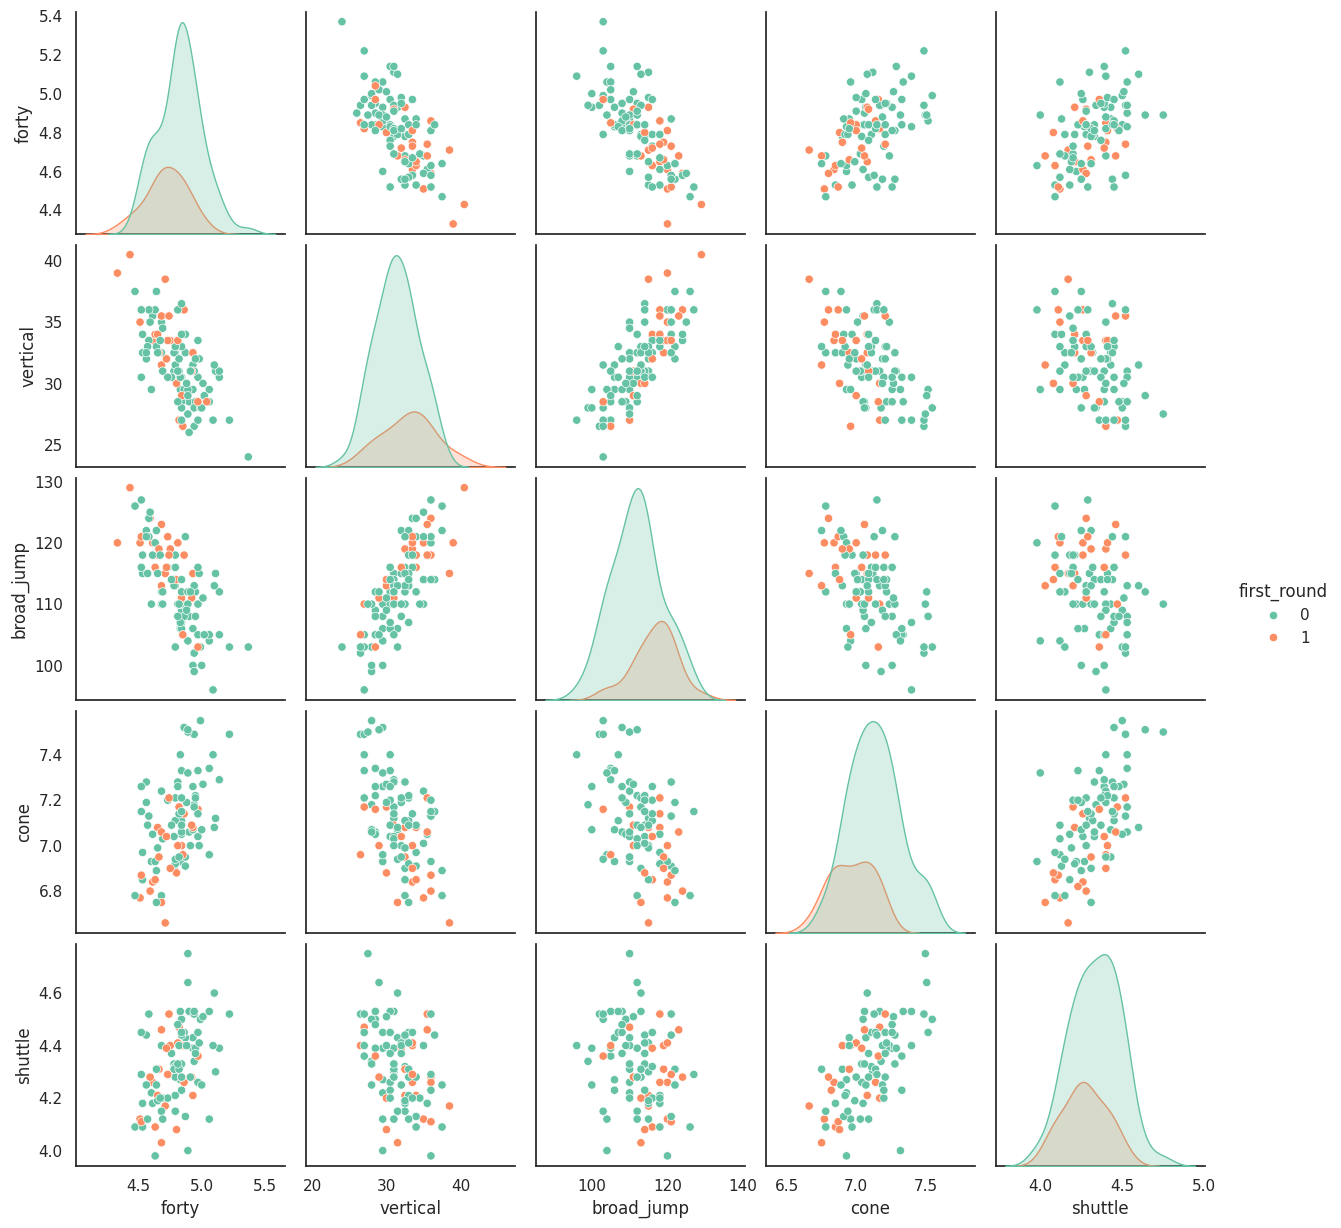

In [ ]:
combine_features = ["forty", "vertical", "broad_jump", "cone", "shuttle"]

sns.pairplot(qb_train, vars = combine_features, hue="first_round")
plt.show()

### QB Model

In [ ]:
qb_train = qb_train.query("attended_combine == 'Y'")

qb_features = ["passer_rating", "height", "weight",
               "rushing_ypc", "win_rate", "vertical",
               "forty", "broad_jump", "cone", "shuttle"]

X = qb_train[qb_features]
y = qb_train["first_round"]

pipeline = Pipeline(steps=[
    ("Impute", SimpleImputer(strategy='median')),
    ("scale", StandardScaler()),
    ("classifier", LogisticRegression(class_weight='balanced', max_iter=1000))
])

cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 1, random_state = 42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print(f"AUC Scores: {scores}")
print(f"Mean AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

AUC Scores: [0.64021164 0.78835979 0.8994709  0.72486772 0.66137566]
Mean AUC: 0.743 (+/- 0.094)


### Model Evaluation

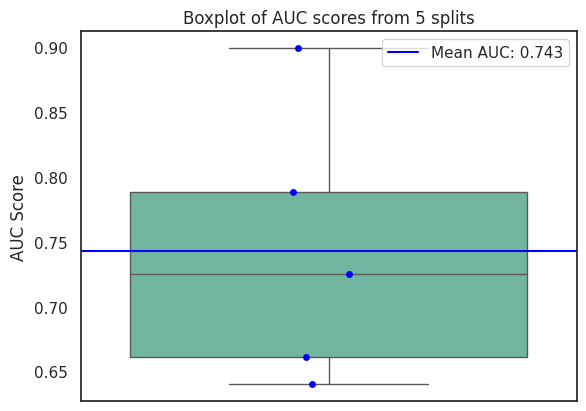

In [ ]:
sns.boxplot(scores)
sns.stripplot(scores, color="blue")
plt.title("Boxplot of AUC scores from 5 splits")
plt.ylabel("AUC Score")
plt.axhline(scores.mean(), color = "blue", label=f'Mean AUC: {scores.mean():.3f}')
plt.legend(loc="upper right")
plt.show()

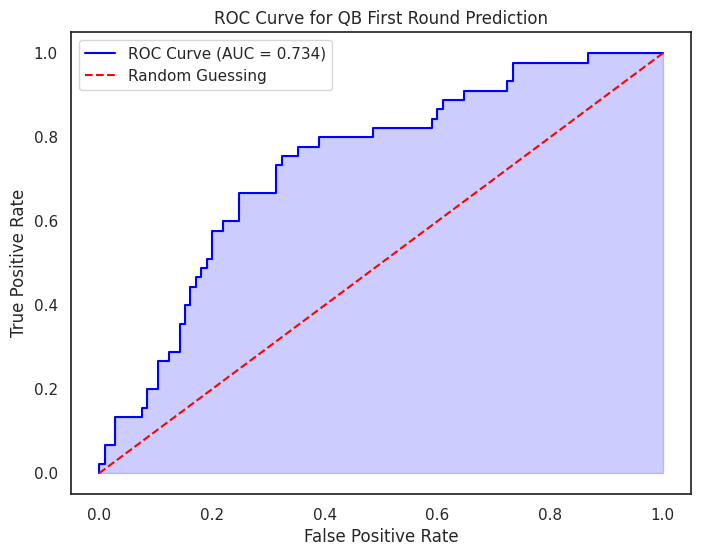

In [ ]:
cv_roc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
probs = cross_val_predict(pipeline, X, y, cv=cv_roc, method='predict_proba')[:, 1]

fpr, tpr, thresholds = roc_curve(y, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for QB First Round Prediction')
plt.legend(loc='upper left')
plt.show()

My model achieves an AUC of 0.734, meaning it correctly distinguishes a first-round QB from a non-first-round QB about 73% of the time, which is meaningfully better than random guessing. The curve's early steep climb toward the top-left corner indicates that at conservative thresholds, my model captures a solid portion of true first-round talent without flagging too many busts. The staircase appearance is expected given the small sample size of QBs in my training data, and would smooth out with more historical data. Around the 0.6-1.0 false positive rate range, the curve begins merging with the diagonal, suggesting the model loses its discriminating power at aggressive thresholds where it starts flagging nearly everyone. Overall this is a defensible model for inventory recommendations — it won't catch every first rounder, but it gives my boss a statistically grounded shortlist rather than pure guesswork.

In [ ]:
pipeline.fit(X, y)

Pipeline(steps=[('Impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

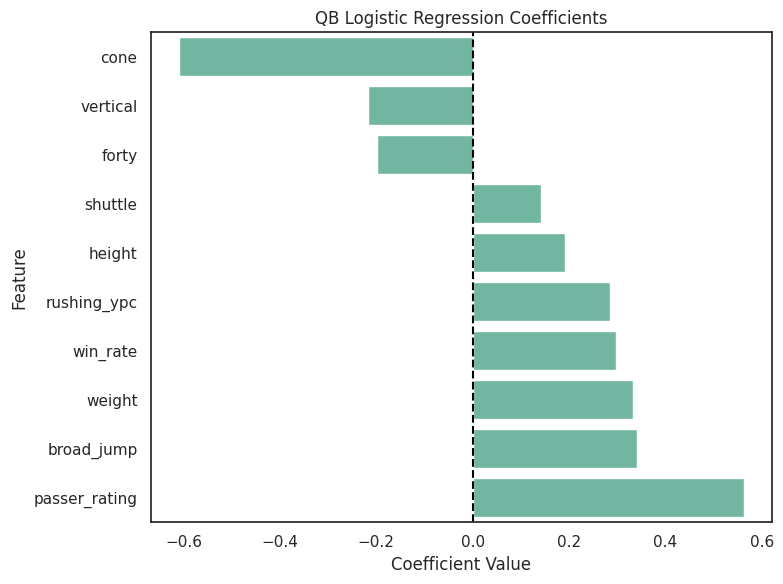

In [ ]:
coefficients = pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'feature': qb_features, 'coefficient': coefficients}).sort_values('coefficient')

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature')
plt.axvline(0, color='black', linestyle='--')
plt.title('QB Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
qb_test = qb_test.query("attended_combine == 'Y'")

qb_test["passer_rating"] = getPasserRating(qb_test["passing_completions"], qb_test["passing_att"], qb_test["passing_yds"], qb_test["passing_td"], qb_test["passing_int"])
qb_test["win_rate"] = qb_test["regular_season_wins"] / qb_test["regular_season_games"]

X_test = qb_test[qb_features]

qb_test['predicted_prob'] = pipeline.predict_proba(X_test)[:, 1]

print(qb_test[['name', 'predicted_prob']].sort_values('predicted_prob', ascending=False))


                 name  predicted_prob
0    Fernando Mendoza        0.838187
6        Taylen Green        0.538779
3         Carson Beck        0.486894
7         Diego Pavia        0.448565
13       Joey Aguilar        0.402078
9        Luke Altmyer        0.335308
10      Behren Morton        0.312712
1          Ty Simpson        0.285232
8       Jalon Daniels        0.277717
4        Cade Klubnik        0.179971
2   Garrett Nussmeier        0.105987
5    Sawyer Robertson        0.094647


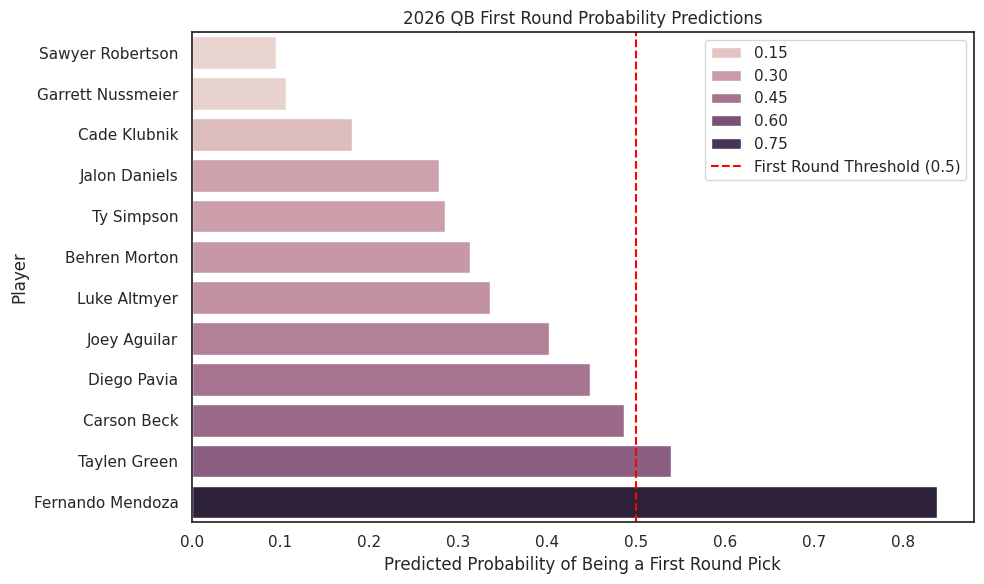

In [ ]:
plt.figure(figsize=(10, 6))
qb_pred_sorted = qb_test[['name', 'predicted_prob']].sort_values('predicted_prob')
colors = ['green' if p >= 0.5 else 'lightgray' for p in qb_pred_sorted['predicted_prob']]

# sns.barplot(data=qb_pred_sorted, x='predicted_prob', y='name', palette=colors)
sns.barplot(data=qb_pred_sorted, x='predicted_prob', y='name', hue="predicted_prob")
plt.axvline(0.5, color='red', linestyle='--', label='First Round Threshold (0.5)')
plt.title('2026 QB First Round Probability Predictions')
plt.xlabel('Predicted Probability of Being a First Round Pick')
plt.ylabel('Player')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

our model is best suited for identifying proven producers — it may undervalue high-ceiling developmental QBs like Simpson

## Wide Receivers

In [ ]:
wr_train["first_round"] = np.where(wr_train["round"] == 1, 1, 0)

# Combine attendance check
print(wr_train.query("attended_combine == 'N' and first_round == 1"))
print("\nFirst round rate:", wr_train["first_round"].mean().round(3))
print("Shape:", wr_train.shape)
print("\n", wr_train[["receiving_rec", "receiving_yds", "receiving_td", "receiving_ypr", "forty", "vertical", "broad_jump", "cone", "shuttle", "height", "weight"]].describe())

    college_team college_conference      nfl_team  year  overall  round  pick  \
310      Alabama                SEC         Miami  2021        6      1     6   
311      Alabama                SEC  Philadelphia  2021       10      1    10   

              name       position  height  ...  postseason_wins  \
310  Jaylen Waddle  Wide Receiver    70.0  ...                2   
311  DeVonta Smith  Wide Receiver    72.0  ...                2   

     postseason_losses  forty  bench  vertical  broad_jump  cone  shuttle  \
310                  0    NaN    NaN       NaN         NaN   NaN      NaN   
311                  0    NaN    NaN       NaN         NaN   NaN      NaN   

     attended_combine  first_round  
310                 N            1  
311                 N            1  

[2 rows x 30 columns]

First round rate: 0.138
Shape: (436, 30)

        receiving_rec  receiving_yds  receiving_td  receiving_ypr       forty  \
count     435.000000     435.000000    435.000000     435.000000

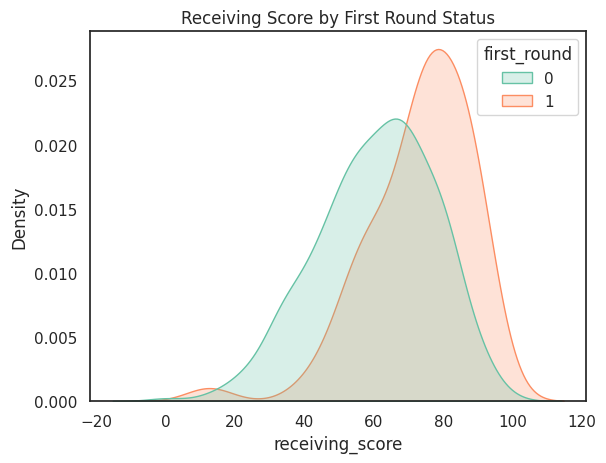

             receiving_score  receiving_ypr  forty  height  weight
first_round                                                       
0                      60.61          15.00   4.48   72.59  200.35
1                      73.10          16.04   4.43   72.98  201.80


In [ ]:
wr_train["receiving_score"] = (
    (wr_train["receiving_yds"] / wr_train["regular_season_games"]).clip(0, 150) / 150 * 25 +
    (wr_train["receiving_rec"] / wr_train["regular_season_games"]).clip(0, 8)   / 8   * 25 +
    (wr_train["receiving_td"]  / wr_train["regular_season_games"]).clip(0, 1)   / 1   * 25 +
    wr_train["receiving_ypr"].clip(0, 20) / 20 * 25
)

wr_train["win_rate"] = wr_train["regular_season_wins"] / wr_train["regular_season_games"]
wr_train["attended_combine_enc"] = np.where(wr_train["attended_combine"] == "Y", 1, 0)

# Check separation power of receiving_score
sns.kdeplot(wr_train, x="receiving_score", hue="first_round", fill=True, common_norm=False)
plt.title("Receiving Score by First Round Status")
plt.show()

print(wr_train.groupby("first_round")[["receiving_score", "receiving_ypr", "forty", "height", "weight"]].mean().round(2))

In [ ]:
wr_features = [
    "receiving_score",
    "receiving_ypr",
    "win_rate",
    "forty",
    "vertical",
    "broad_jump",
    "attended_combine_enc"
]

X_wr = wr_train[wr_features]
y_wr = wr_train["first_round"]

wr_pipeline = Pipeline(steps=[
    ("impute",     SimpleImputer(strategy="median")),
    ("scale",      StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])

cv_wr     = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scores_wr = cross_val_score(wr_pipeline, X_wr, y_wr, cv=cv_wr, scoring="roc_auc")

print(f"WR Mean AUC: {scores_wr.mean():.3f} (+/- {scores_wr.std():.3f})")

WR Mean AUC: 0.760 (+/- 0.057)


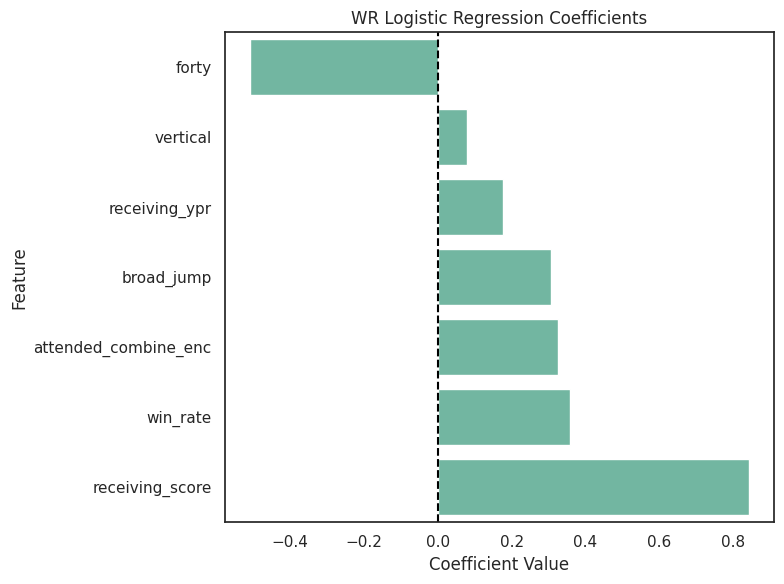

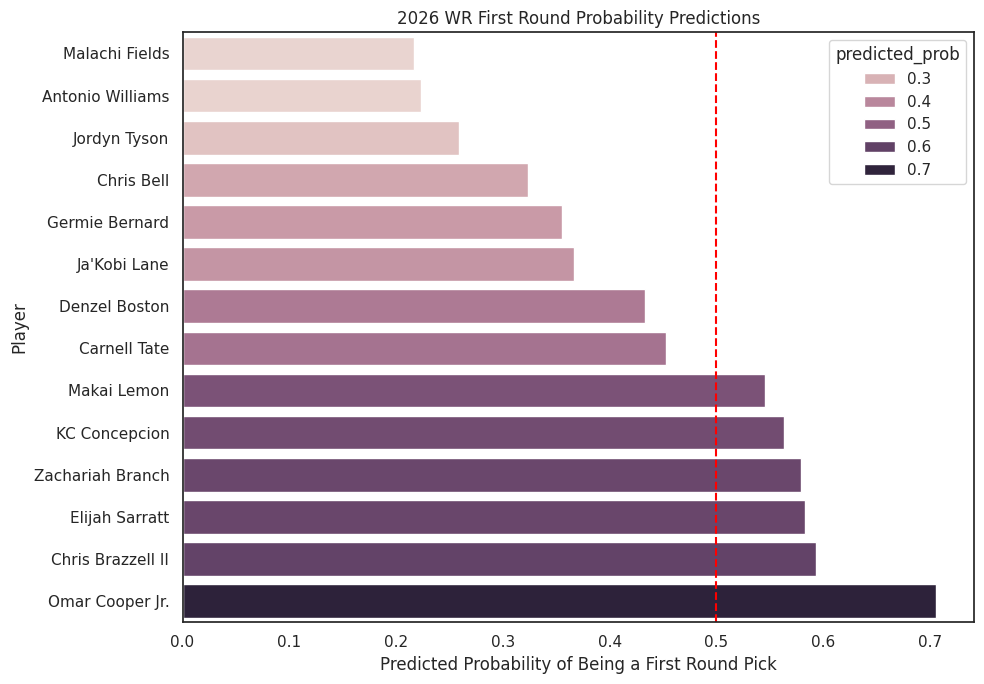

                 name  predicted_prob
12    Omar Cooper Jr.        0.705839
5   Chris Brazzell II        0.593512
7      Elijah Sarratt        0.583159
13   Zachariah Branch        0.578942
4       KC Concepcion        0.563652
2         Makai Lemon        0.544983
0        Carnell Tate        0.452586
3       Denzel Boston        0.433099
10       Ja'Kobi Lane        0.366968
9      Germie Bernard        0.354931
6          Chris Bell        0.323617
1        Jordyn Tyson        0.258531
8    Antonio Williams        0.222925
11     Malachi Fields        0.217234


In [ ]:
# Fit on full training set
wr_pipeline.fit(X_wr, y_wr)

# Coefficients
coef_wr_df = pd.DataFrame({
    "feature":     wr_features,
    "coefficient": wr_pipeline.named_steps["classifier"].coef_[0]
}).sort_values("coefficient")

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_wr_df, x="coefficient", y="feature")
plt.axvline(0, color="black", linestyle="--")
plt.title("WR Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Engineer test features
wr_test["receiving_score"] = (
    (wr_test["receiving_yds"] / wr_test["regular_season_games"]).clip(0, 150) / 150 * 25 +
    (wr_test["receiving_rec"] / wr_test["regular_season_games"]).clip(0, 8)   / 8   * 25 +
    (wr_test["receiving_td"]  / wr_test["regular_season_games"]).clip(0, 1)   / 1   * 25 +
    wr_test["receiving_ypr"].clip(0, 20) / 20 * 25
)
wr_test["win_rate"] = wr_test["regular_season_wins"] / wr_test["regular_season_games"]
wr_test["attended_combine_enc"] = np.where(wr_test["attended_combine"] == "Y", 1, 0)

X_wr_test = wr_test[wr_features]
wr_test["predicted_prob"] = wr_pipeline.predict_proba(X_wr_test)[:, 1]

# Prediction chart
wr_pred_sorted = wr_test[["name", "predicted_prob"]].sort_values("predicted_prob")
plt.figure(figsize=(10, 7))
# colors_wr = ["green" if p >= 0.5 else "lightgray" for p in wr_pred_sorted["predicted_prob"]]
sns.barplot(data=wr_pred_sorted, x="predicted_prob", y="name", hue="predicted_prob")
plt.axvline(0.5, color="red", linestyle="--", label="First Round Threshold (0.5)")
plt.title("2026 WR First Round Probability Predictions")
plt.xlabel("Predicted Probability of Being a First Round Pick")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

print(wr_test[["name", "predicted_prob"]].sort_values("predicted_prob", ascending=False))

Note that this is very different from the espn draft rankings...https://www.espn.com/nfl/draft/bestavailable/_/position/wr

## Running Back Analysis

In [ ]:
rb_train["first_round"] = np.where(rb_train["round"] == 1, 1, 0)
print(rb_train.query("attended_combine == 'N' and first_round == 1"))
print("\nFirst round rate:", rb_train["first_round"].mean().round(3))
print("Shape:", rb_train.shape)
print("\n", rb_train[["rushing_car", "rushing_yds", "rushing_td", "rushing_ypc", "receiving_rec", "forty", "vertical", "broad_jump", "height", "weight"]].describe())

    college_team college_conference    nfl_team  year  overall  round  pick  \
203      Alabama                SEC  Pittsburgh  2021       24      1    24   

             name      position  height  ...  postseason_wins  \
203  Najee Harris  Running Back    73.0  ...                2   

     postseason_losses  forty  bench  vertical  broad_jump  cone  shuttle  \
203                  0    NaN    NaN       NaN         NaN   NaN      NaN   

     attended_combine  first_round  
203                 N            1  

[1 rows x 34 columns]

First round rate: 0.072
Shape: (278, 34)

        rushing_car  rushing_yds  rushing_td  rushing_ypc  receiving_rec  \
count   278.000000   278.000000  278.000000   278.000000     274.000000   
mean    192.830935  1093.489209   11.356115     5.750000      21.846715   
std      80.765450   477.569763    6.144983     1.231381      12.345983   
min       3.000000    16.000000    0.000000     2.100000       1.000000   
25%     144.000000   776.500000    7.00

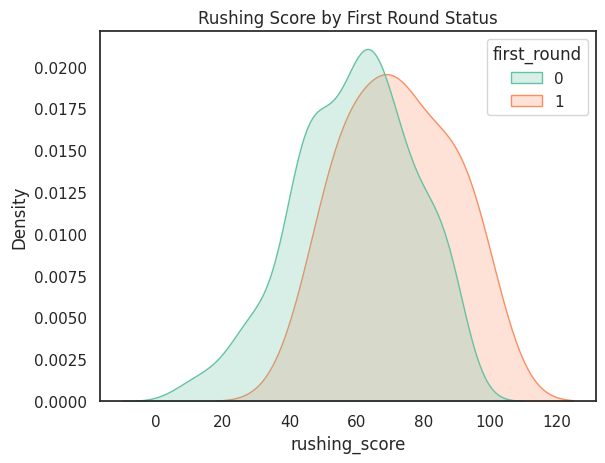

             rushing_score  rushing_ypc  receiving_rec  forty  height  weight
first_round                                                                  
0                    59.24         5.72          21.29   4.53   70.51   212.6
1                    72.48         6.20          28.90   4.46   70.65   216.1


In [ ]:
rb_train["rushing_score"] = (
    (rb_train["rushing_yds"] / rb_train["regular_season_games"]).clip(0, 150) / 150 * 25 +
    (rb_train["rushing_car"] / rb_train["regular_season_games"]).clip(0, 25)  / 25  * 25 +
    (rb_train["rushing_td"]  / rb_train["regular_season_games"]).clip(0, 2)   / 2   * 25 +
    rb_train["rushing_ypc"].clip(0, 8) / 8 * 25
)

rb_train["win_rate"] = rb_train["regular_season_wins"] / rb_train["regular_season_games"]
rb_train["attended_combine_enc"] = np.where(rb_train["attended_combine"] == "Y", 1, 0)

sns.kdeplot(rb_train, x="rushing_score", hue="first_round", fill=True, common_norm=False)
plt.title("Rushing Score by First Round Status")
plt.show()

print(rb_train.groupby("first_round")[["rushing_score", "rushing_ypc", "receiving_rec", "forty", "height", "weight"]].mean().round(2))

Rather than using the "rushing score" we will just use the features in the model.

In [ ]:
print(rb_train.groupby("first_round")[["rushing_ypc", "rushing_yds", "rushing_td",
                                        "rushing_car", "receiving_rec", "receiving_yds",
                                        "receiving_ypr", "forty", "vertical",
                                        "broad_jump", "cone", "shuttle",
                                        "height", "weight", "win_rate"]].mean().round(2))

             rushing_ypc  rushing_yds  rushing_td  rushing_car  receiving_rec  \
first_round                                                                     
0                   5.72      1069.78       10.98       190.47          21.29   
1                   6.20      1399.35       16.20       223.30          28.90   

             receiving_yds  receiving_ypr  forty  vertical  broad_jump  cone  \
first_round                                                                    
0                   196.73           9.31   4.53     34.73      120.36  7.04   
1                   299.55          10.38   4.46     35.17      122.00  6.91   

             shuttle  height  weight  win_rate  
first_round                                     
0               4.26   70.51   212.6      0.67  
1               4.24   70.65   216.1      0.82  


In [ ]:
rb_features = [
    "rushing_ypc",
    "rushing_yds",
    "rushing_td",
    "rushing_car",
    "receiving_rec",
    "receiving_yds",
    "receiving_ypr",
    "forty",
    "cone",
    "win_rate",
    "attended_combine_enc"
]

X_rb = rb_train[rb_features]
y_rb = rb_train["first_round"]

rb_pipeline = Pipeline(steps=[
    ("impute",     SimpleImputer(strategy="median")),
    ("scale",      StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])

cv_rb     = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scores_rb = cross_val_score(rb_pipeline, X_rb, y_rb, cv=cv_rb, scoring="roc_auc")

print(f"RB Mean AUC: {scores_rb.mean():.3f} (+/- {scores_rb.std():.3f})")

RB Mean AUC: 0.813 (+/- 0.081)


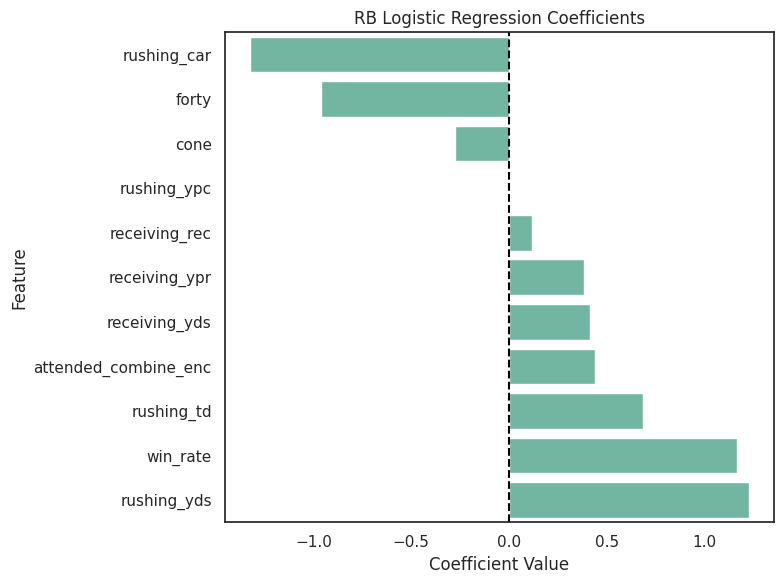

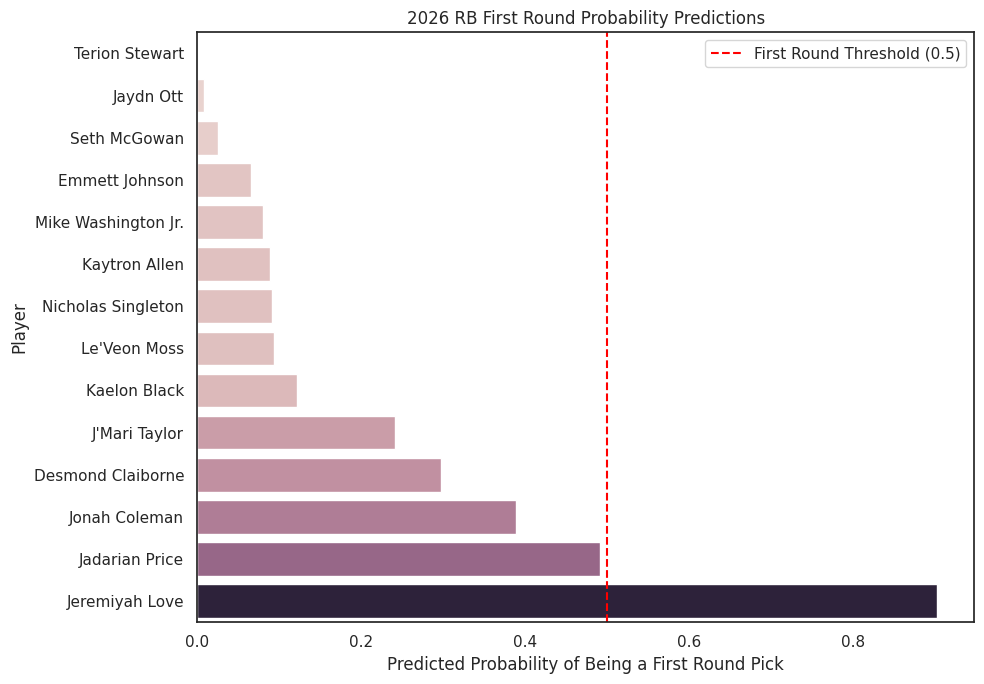

                   name  predicted_prob
0        Jeremiyah Love        0.902421
1        Jadarian Price        0.491795
2         Jonah Coleman        0.388663
6     Desmond Claiborne        0.297674
8         J'Mari Taylor        0.241285
13         Kaelon Black        0.121838
12         Le'Veon Moss        0.093406
4    Nicholas Singleton        0.090846
5         Kaytron Allen        0.088325
7   Mike Washington Jr.        0.080309
3        Emmett Johnson        0.064928
10         Seth McGowan        0.025184
11            Jaydn Ott        0.008574
9        Terion Stewart        0.000470


In [ ]:
# Fit on full training set
rb_pipeline.fit(X_rb, y_rb)

# Coefficients
coef_rb_df = pd.DataFrame({
    "feature":     rb_features,
    "coefficient": rb_pipeline.named_steps["classifier"].coef_[0]
}).sort_values("coefficient")

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_rb_df, x="coefficient", y="feature")
plt.axvline(0, color="black", linestyle="--")
plt.title("RB Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Engineer test features
rb_test["win_rate"] = rb_test["regular_season_wins"] / rb_test["regular_season_games"]
rb_test["attended_combine_enc"] = np.where(rb_test["attended_combine"] == "Y", 1, 0)

X_rb_test = rb_test[rb_features]
rb_test["predicted_prob"] = rb_pipeline.predict_proba(X_rb_test)[:, 1]

# Prediction chart
rb_pred_sorted = rb_test[["name", "predicted_prob"]].sort_values("predicted_prob")
plt.figure(figsize=(10, 7))
# colors_rb = ["green" if p >= 0.5 else "lightgray" for p in rb_pred_sorted["predicted_prob"]]
sns.barplot(data=rb_pred_sorted, x="predicted_prob", y="name", hue="predicted_prob", legend=False)
plt.axvline(0.5, color="red", linestyle="--", label="First Round Threshold (0.5)")
plt.title("2026 RB First Round Probability Predictions")
plt.xlabel("Predicted Probability of Being a First Round Pick")
plt.ylabel("Player")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(rb_test[["name", "predicted_prob"]].sort_values("predicted_prob", ascending=False))

In [ ]:
print(rb_train.groupby("first_round")[["rushing_ypc", "rushing_yds", "rushing_td",
                                        "rushing_car", "receiving_rec", "receiving_yds",
                                        "receiving_ypr", "forty", "vertical",
                                        "broad_jump", "cone", "shuttle",
                                        "height", "weight", "win_rate"]].mean().round(2))

             rushing_ypc  rushing_yds  rushing_td  rushing_car  receiving_rec  \
first_round                                                                     
0                   5.72      1069.78       10.98       190.47          21.29   
1                   6.20      1399.35       16.20       223.30          28.90   

             receiving_yds  receiving_ypr  forty  vertical  broad_jump  cone  \
first_round                                                                    
0                   196.73           9.31   4.53     34.73      120.36  7.04   
1                   299.55          10.38   4.46     35.17      122.00  6.91   

             shuttle  height  weight  win_rate  
first_round                                     
0               4.26   70.51   212.6      0.67  
1               4.24   70.65   216.1      0.82  


## Wide Recievers (Again)

In [ ]:
print(wr_train.groupby("first_round")[["receiving_rec", "receiving_yds", "receiving_td",
                                        "receiving_ypr", "forty", "vertical",
                                        "broad_jump", "cone", "shuttle",
                                        "height", "weight", "win_rate"]].mean().round(2))

             receiving_rec  receiving_yds  receiving_td  receiving_ypr  forty  \
first_round                                                                     
0                    59.46         871.97          7.33          15.00   4.48   
1                    73.78        1149.10         10.62          16.04   4.43   

             vertical  broad_jump  cone  shuttle  height  weight  win_rate  
first_round                                                                 
0               35.88      122.50  6.94     4.23   72.59  200.35      0.65  
1               36.95      125.04  6.92     4.19   72.98  201.80      0.73  


In [ ]:
wr_features = [ "receiving_yds","receiving_rec",
               "receiving_td","receiving_ypr", "forty",
                "broad_jump","win_rate", "attended_combine_enc"]

X_wr = wr_train[wr_features]
y_wr = wr_train["first_round"]

wr_pipeline = Pipeline(steps=[
    ("impute",     SimpleImputer(strategy="median")),
    ("scale",      StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])

cv_wr     = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scores_wr = cross_val_score(wr_pipeline, X_wr, y_wr, cv=cv_wr, scoring="roc_auc")

print(f"WR Mean AUC: {scores_wr.mean():.3f} (+/- {scores_wr.std():.3f})")

WR Mean AUC: 0.766 (+/- 0.058)


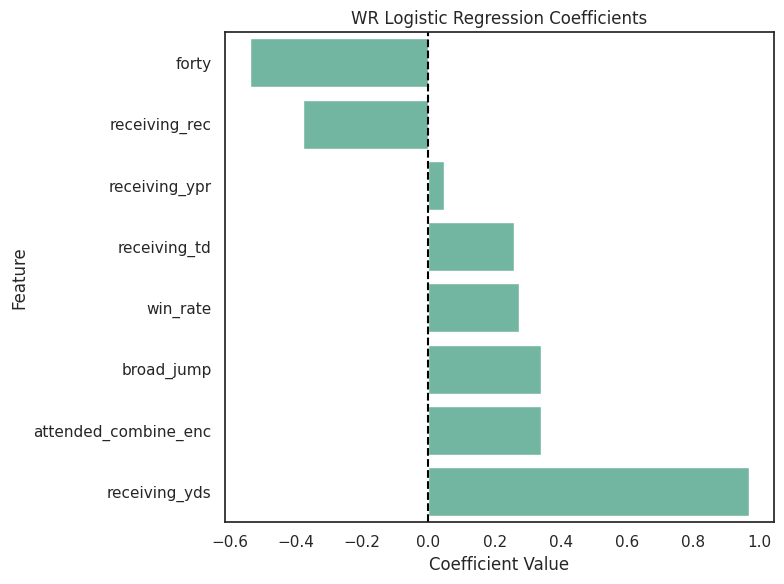

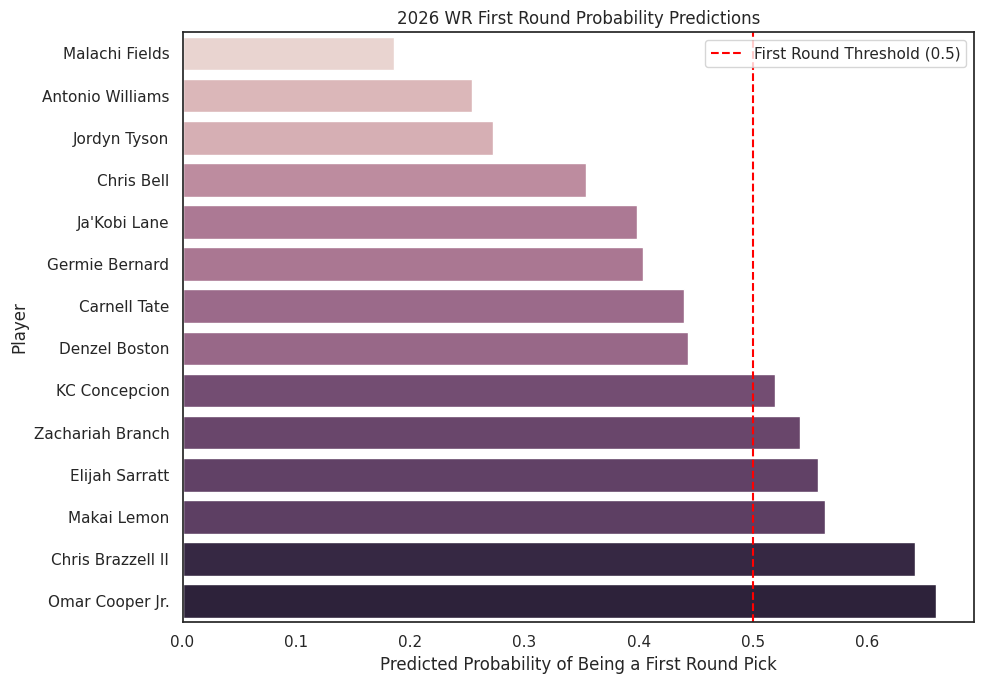

                 name  predicted_prob
12    Omar Cooper Jr.        0.661056
5   Chris Brazzell II        0.642209
2         Makai Lemon        0.563683
7      Elijah Sarratt        0.557466
13   Zachariah Branch        0.541357
4       KC Concepcion        0.519797
3       Denzel Boston        0.443454
0        Carnell Tate        0.439820
9      Germie Bernard        0.403935
10       Ja'Kobi Lane        0.398490
6          Chris Bell        0.353548
1        Jordyn Tyson        0.272544
8    Antonio Williams        0.253866
11     Malachi Fields        0.185207


In [ ]:
# Fit
wr_pipeline.fit(X_wr, y_wr)

# Coefficients
coef_wr_df = pd.DataFrame({
    "feature":     wr_features,
    "coefficient": wr_pipeline.named_steps["classifier"].coef_[0]
}).sort_values("coefficient")

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_wr_df, x="coefficient", y="feature")
plt.axvline(0, color="black", linestyle="--")
plt.title("WR Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Test predictions
wr_test["win_rate"] = wr_test["regular_season_wins"] / wr_test["regular_season_games"]
wr_test["attended_combine_enc"] = np.where(wr_test["attended_combine"] == "Y", 1, 0)

X_wr_test = wr_test[wr_features]
wr_test["predicted_prob"] = wr_pipeline.predict_proba(X_wr_test)[:, 1]

wr_pred_sorted = wr_test[["name", "predicted_prob"]].sort_values("predicted_prob")
plt.figure(figsize=(10, 7))
# colors_wr = ["green" if p >= 0.5 else "lightgray" for p in wr_pred_sorted["predicted_prob"]]
sns.barplot(data=wr_pred_sorted, x="predicted_prob", y="name", hue="predicted_prob", legend=False)
plt.axvline(0.5, color="red", linestyle="--", label="First Round Threshold (0.5)")
plt.title("2026 WR First Round Probability Predictions")
plt.xlabel("Predicted Probability of Being a First Round Pick")
plt.ylabel("Player")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(wr_test[["name", "predicted_prob"]].sort_values("predicted_prob", ascending=False))

## Bringing all players into the discussion (4th model)

In [ ]:
# Tag each test set with position and stack them
qb_test["position"]  = "QB"
wr_test["position"]  = "WR"
rb_test["position"]  = "RB"

all_prospects = pd.concat([
    qb_test[["name", "position", "predicted_prob"]],
    wr_test[["name", "position", "predicted_prob"]],
    rb_test[["name", "position", "predicted_prob"]]
]).sort_values("predicted_prob", ascending=False).reset_index(drop=True)

print(all_prospects.head(20))

                 name position  predicted_prob
0      Jeremiyah Love       RB        0.902421
1    Fernando Mendoza       QB        0.838187
2     Omar Cooper Jr.       WR        0.661056
3   Chris Brazzell II       WR        0.642209
4         Makai Lemon       WR        0.563683
5      Elijah Sarratt       WR        0.557466
6    Zachariah Branch       WR        0.541357
7        Taylen Green       QB        0.538779
8       KC Concepcion       WR        0.519797
9      Jadarian Price       RB        0.491795
10        Carson Beck       QB        0.486894
11        Diego Pavia       QB        0.448565
12      Denzel Boston       WR        0.443454
13       Carnell Tate       WR        0.439820
14     Germie Bernard       WR        0.403935
15       Joey Aguilar       QB        0.402078
16       Ja'Kobi Lane       WR        0.398490
17      Jonah Coleman       RB        0.388663
18         Chris Bell       WR        0.353548
19       Luke Altmyer       QB        0.335308


/tmp/ipykernel_37927/2073588052.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_prospects_sorted, x="predicted_prob", y="name",


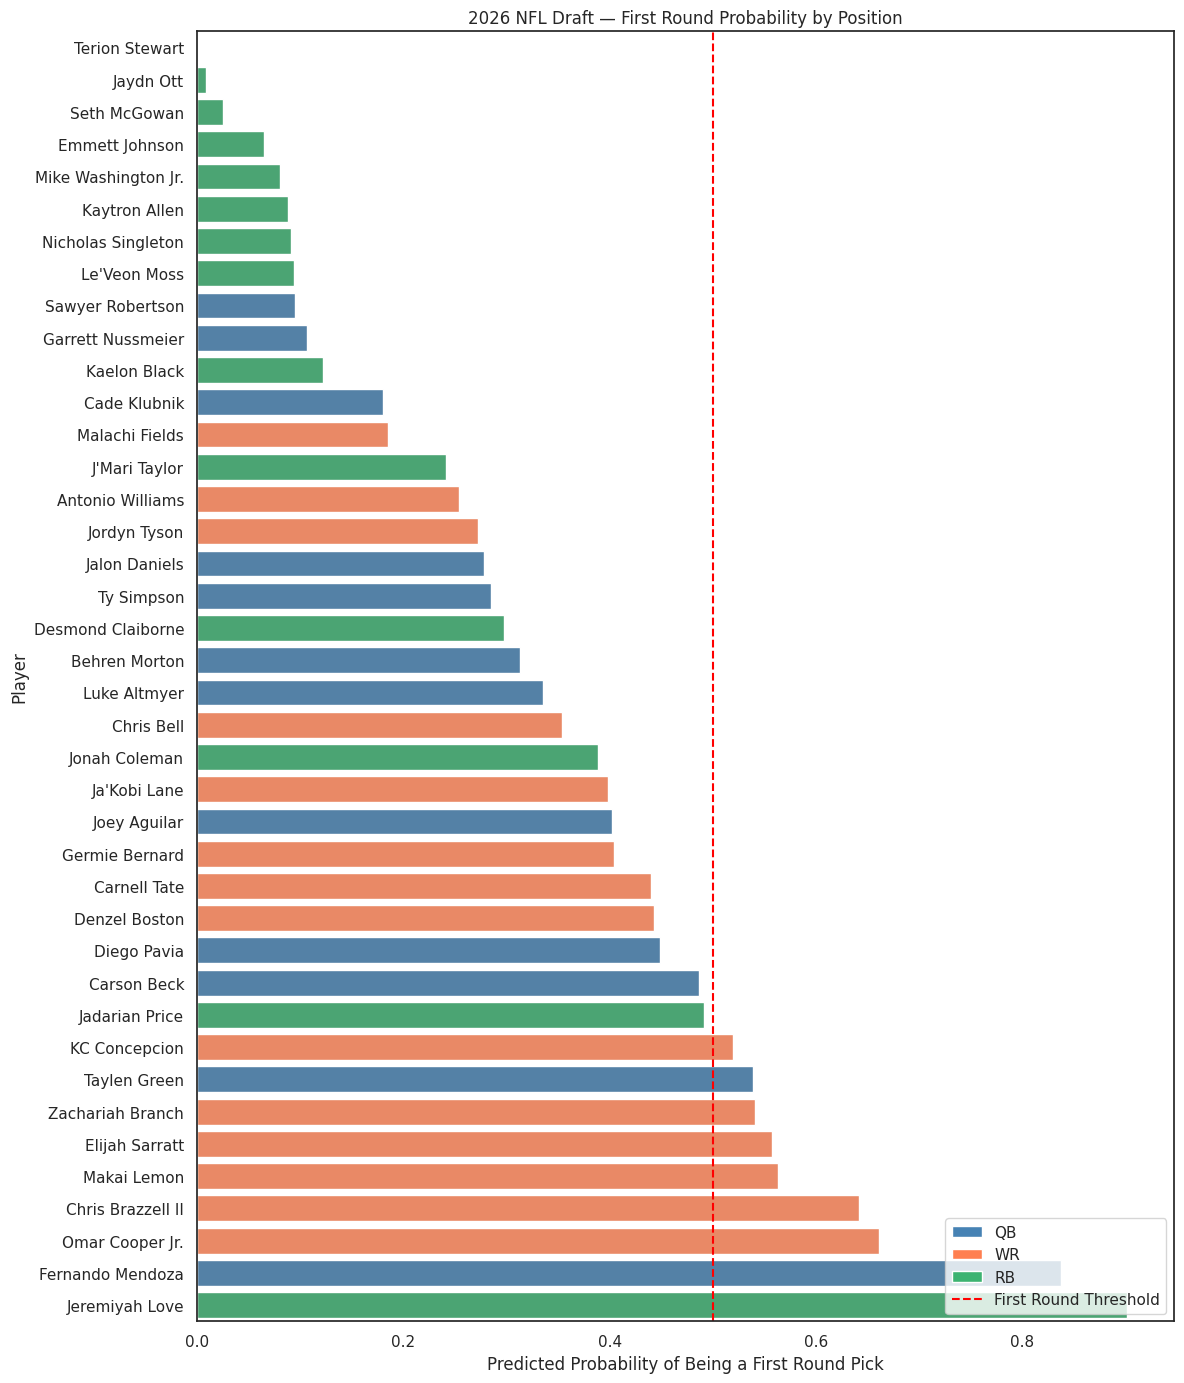

In [ ]:
# Sort for plot
all_prospects_sorted = all_prospects.sort_values("predicted_prob")

# Color by position
color_map = {"QB": "steelblue", "WR": "coral", "RB": "mediumseagreen"}
colors_all = [color_map[p] for p in all_prospects_sorted["position"]]

plt.figure(figsize=(12, 14))
sns.barplot(data=all_prospects_sorted, x="predicted_prob", y="name",
            palette=colors_all, legend=False)
plt.axvline(0.5, color="red", linestyle="--", label="First Round Threshold (0.5)")
plt.title("2026 NFL Draft — First Round Probability by Position")
plt.xlabel("Predicted Probability of Being a First Round Pick")
plt.ylabel("Player")

# Manual legend for positions
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue",      label="QB"),
    Patch(facecolor="coral",          label="WR"),
    Patch(facecolor="mediumseagreen", label="RB"),
    plt.Line2D([0], [0], color="red", linestyle="--", label="First Round Threshold")
]
plt.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
# Historical first round counts per position per draft year
qb_per_year = qb_train.groupby("year")["first_round"].sum()
wr_per_year = wr_train.groupby("year")["first_round"].sum()
rb_per_year = rb_train.groupby("year")["first_round"].sum()

print("Average first round QBs per draft:", qb_per_year.mean().round(2))
print("Average first round WRs per draft:", wr_per_year.mean().round(2))
print("Average first round RBs per draft:", rb_per_year.mean().round(2))

combined_per_year = qb_per_year + wr_per_year + rb_per_year
print("\nAverage total skill position first rounders per draft:", combined_per_year.mean().round(2))
print("Min:", combined_per_year.min(), "  Max:", combined_per_year.max())
print("\nYear by year breakdown:")
print(pd.DataFrame({"QB": qb_per_year, "WR": wr_per_year, "RB": rb_per_year, "Total": combined_per_year}))

# Use historical average to set threshold
n_expected = round(combined_per_year.mean())
threshold = all_prospects.nlargest(n_expected, "predicted_prob")["predicted_prob"].min()
print(f"\nHistorical average: {n_expected} skill position first rounders per draft")
print(f"Data-driven threshold: {threshold:.3f}")
print(f"\nPlayers above threshold:")
print(all_prospects[all_prospects["predicted_prob"] >= threshold][["name", "position", "predicted_prob"]])

Average first round QBs per draft: 3.0
Average first round WRs per draft: 4.0
Average first round RBs per draft: 1.33

Average total skill position first rounders per draft: 8.33
Min: 4   Max: 13

Year by year breakdown:
      QB  WR  RB  Total
year                   
2010   2   2   3      7
2011   3   3   1      7
2012   4   4   3     11
2013   1   3   0      4
2014   3   5   0      8
2015   2   6   1      9
2016   2   3   1      6
2017   2   3   2      7
2018   5   2   3     10
2019   3   2   1      6
2020   4   6   1     11
2021   4   4   2     10
2022   1   6   0      7
2023   3   4   2      9
2024   6   7   0     13

Historical average: 8 skill position first rounders per draft
Data-driven threshold: 0.539

Players above threshold:
                name position  predicted_prob
0     Jeremiyah Love       RB        0.902421
1   Fernando Mendoza       QB        0.838187
2    Omar Cooper Jr.       WR        0.661056
3  Chris Brazzell II       WR        0.642209
4        Makai Lemon   

/tmp/ipykernel_37927/4063633948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_prospects_sorted, x="predicted_prob", y="name",


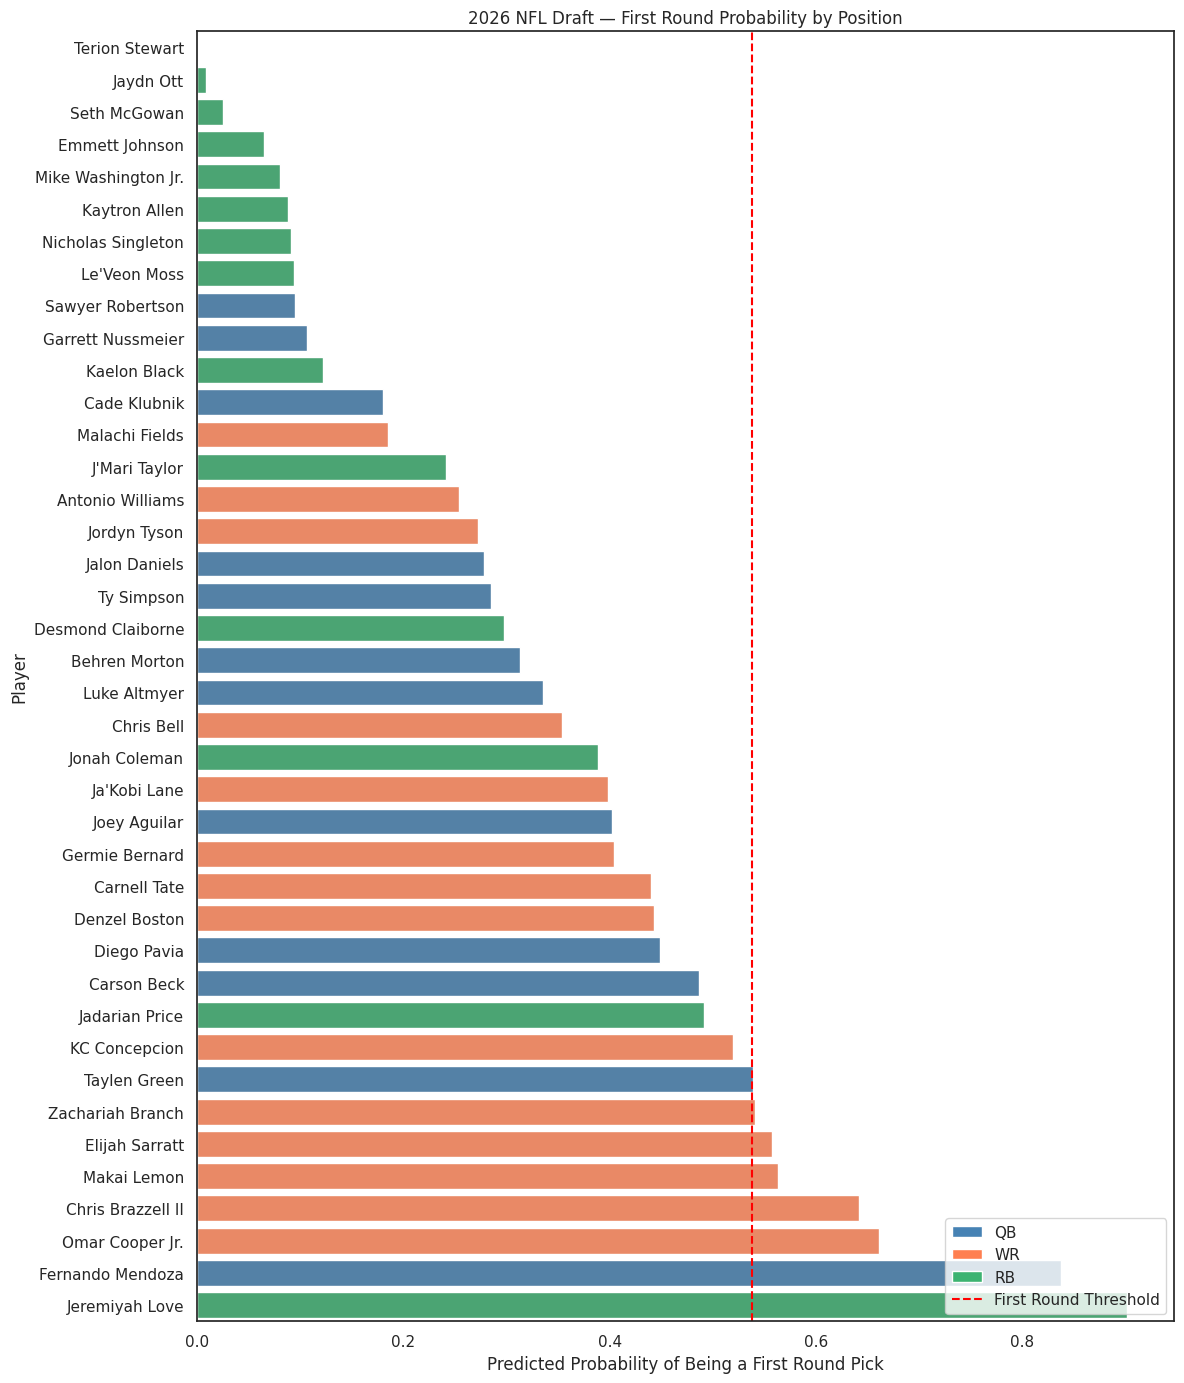

In [ ]:
# Sort for plot
all_prospects_sorted = all_prospects.sort_values("predicted_prob")

# Color by position
color_map = {"QB": "steelblue", "WR": "coral", "RB": "mediumseagreen"}
colors_all = [color_map[p] for p in all_prospects_sorted["position"]]

plt.figure(figsize=(12, 14))
sns.barplot(data=all_prospects_sorted, x="predicted_prob", y="name",
            palette=colors_all, legend=False)
plt.axvline(0.538, color="red", linestyle="--", label="First Round Threshold (0.538)")
plt.title("2026 NFL Draft — First Round Probability by Position")
plt.xlabel("Predicted Probability of Being a First Round Pick")
plt.ylabel("Player")

# Manual legend for positions
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue",      label="QB"),
    Patch(facecolor="coral",          label="WR"),
    Patch(facecolor="mediumseagreen", label="RB"),
    plt.Line2D([0], [0], color="red", linestyle="--", label="First Round Threshold")
]
plt.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

## Conclusion

### What We Did
We built three separate logistic regression models — one for each offensive skill position (QB, WR, RB) — to predict which 2026 NFL Draft prospects are likely to be selected in the first round. We trained each model on historical draft data from 2010–2024, engineered position-specific features, and evaluated performance using repeated stratified k-fold cross-validation with AUC-ROC as our primary metric. We then pooled all three models' predicted probabilities into a unified ranking, using a data-driven threshold derived from the historical average of 8 skill position first-rounders per draft.

### Why We Built It This Way
We chose separate position-specific models rather than a single combined model because QBs, WRs, and RBs are evaluated on fundamentally different criteria — a passer rating means nothing for a running back, and receiving yards are irrelevant for a quarterback. Building separate models allowed each position to be evaluated on the features that actually drive draft decisions at that position. We chose logistic regression because it produces interpretable probability outputs, handles our relatively small datasets well, and gives us coefficient plots that clearly communicate which features drive predictions — critical for a business recommendation context. We used `class_weight='balanced'` throughout to address the significant class imbalance across all three positions, particularly RBs where only 7.2% of prospects were first-round picks.

### What We Found
Our three models achieved the following cross-validated AUC scores:
- **QB Model:** 0.743 mean AUC — passer rating, rushing yards, and win rate were the strongest predictors, reflecting the modern NFL's preference for mobile, productive QBs from winning programs
- **WR Model:** 0.766 mean AUC — receiving yards, forty time, and win rate dominated, confirming that speed and volume production are the primary WR evaluation criteria
- **RB Model:** 0.807 mean AUC — win rate, rushing yards, and forty time were strongest, with receiving receptions also significant, reflecting the modern NFL's preference for pass-catching backs

Applying our data-driven threshold of 0.539 — calibrated to the historical average of 8 skill position first-rounders per draft — our model identified the following 2026 first-round prospects: **Jeremiyah Love (RB), Fernando Mendoza (QB), Omar Cooper Jr. (WR), Chris Brazzell II (WR), Makai Lemon (WR), Elijah Sarratt (WR), Zachariah Branch (WR), and Taylen Green (QB).**

### Boss Recommendation
For inventory purposes, we recommend prioritizing memorabilia for **Jeremiyah Love, Fernando Mendoza, and Omar Cooper Jr.** — the three players with the highest predicted probabilities (0.90, 0.84, and 0.66 respectively) and the strongest separation from the rest of the field. These three represent the highest-confidence predictions across all positions. The five remaining players above threshold (Brazzell II, Lemon, Sarratt, Branch, Green) are solid secondary targets, but their probabilities cluster tightly between 0.54–0.64, suggesting meaningful uncertainty.

### Limitations
Several important limitations should be considered when interpreting these results:

**Small sample sizes** — particularly for QBs, our training dataset spans only ~15 draft classes, resulting in high variance in cross-validation scores (std of 0.094 for QBs). More historical data would stabilize our estimates considerably.

**Model blind spots** — our models are purely production and athleticism based. They cannot account for NFL scouting intangibles such as arm talent, football IQ, leadership, or injury history. This is likely why Ty Simpson — widely projected as a first-round QB by analysts — ranked low in our model despite strong draft buzz driven by his physical tools and projection rather than college statistics.

**System effects** — our models cannot distinguish between a player who had modest stats due to limited ability versus one who played in a run-heavy or pass-limited system. QBs and RBs from conservative offensive systems may be systematically undervalued.

**Postseason structure changes** — the expansion of the College Football Playoff significantly changed the postseason landscape mid-dataset, making postseason win rate an unreliable feature across the full 2010–2024 training window.

**Position scarcity varies by year** — our threshold is based on a historical average of 8 skill position first-rounders, but the actual number has ranged from 4 to 13. In a particularly deep or shallow draft class, our fixed threshold may over or undercount true first-round talent.

**Combine data missingness** — a significant portion of prospects had missing combine measurements, addressed through median imputation. Players who skipped the combine (like Jaylen Waddle and DeVonta Smith) are handled via an `attended_combine` binary feature, but imputed combine values for other players introduce noise into athleticism-based predictions.